# Tutorial 2 — Classification with scikit-learn
**AIMS Ghana — Machine Learning Course, 2025**

---

## Overview

This tutorial uses **scikit-learn** to solve a binary classification problem.
We compare four classifiers on an exam-score admission dataset.

| Classifier | Key Hyperparameter |
|---|---|
| Logistic Regression | Regularisation `C` |
| Support Vector Machine (SVM) | Kernel, `C` |
| K-Nearest Neighbours (KNN) | Number of neighbours `k` |
| Decision Tree | Maximum depth |

**Dataset:** `ex2data1.txt` — two exam scores, binary admission label.

> This tutorial is designed to help you familiarise with the `scikit-learn` library.
> You are encouraged to change the default parameters and observe the effect.


## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
plt.style.use('ggplot')


## 2. Load and Visualise Data

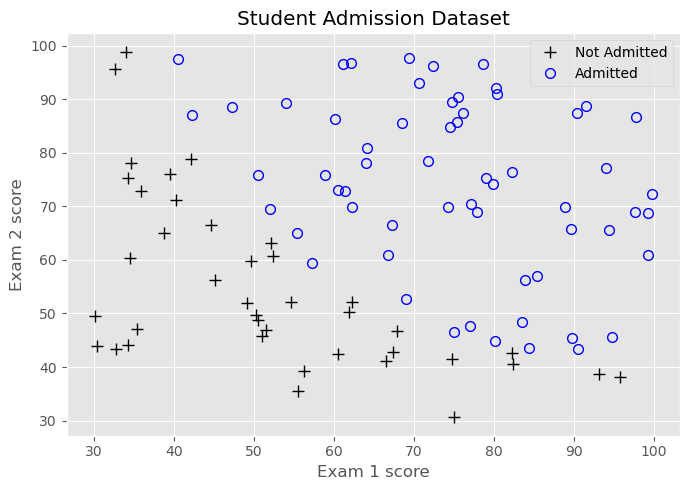

Dataset: 100 students  |  60 admitted  |  40 not admitted


In [3]:
clf_data = np.loadtxt('data/ex2data1.txt', dtype=float, delimiter=',')
x = clf_data[:, :2]    # [Exam 1 score, Exam 2 score]
y = clf_data[:, -1]    # 0 = Not Admitted, 1 = Admitted

neg = np.where(y == 0.0)[0]   # indices where y = 0
pos = np.where(y == 1.0)[0]   # indices where y = 1

plt.figure(figsize=(7, 5))
plt.plot(x[neg, 0], x[neg, 1], 'k+', markersize=8, label='Not Admitted')
plt.plot(x[pos, 0], x[pos, 1], 'bo', markersize=7,
         markerfacecolor='none', label='Admitted')
plt.xlabel('Exam 1 score'); plt.ylabel('Exam 2 score')
plt.title('Student Admission Dataset'); plt.legend()
plt.tight_layout(); plt.show()
print(f'Dataset: {len(x)} students  |  {len(pos)} admitted  |  {len(neg)} not admitted')


## 3. Logistic Regression

**Instructions:**
1. Use `LogisticRegression` from scikit-learn
2. Fit the training set
3. Plot the decision boundary
4. Predict the class of `[45, 85]`

**Theory:** Logistic regression models $P(y=1 \mid x) = \sigma(\theta^T x)$.
The decision boundary is linear: $\theta^T x = 0$.


In [4]:
# 1. Fit Logistic Regression
cdf = LogisticRegression(random_state=0, max_iter=1000)
cdf.fit(x, y)

# 4. Predict
pred = cdf.predict([[45, 85]])
prob = cdf.predict_proba([[45, 85]])[0]
print(f'Prediction for [45, 85]: {"Admitted" if pred[0]==1 else "Not Admitted"}')
print(f'Probability of admission: {prob[1]:.3f}')
print(f'Coefficients: {cdf.coef_[0]}  |  Intercept: {cdf.intercept_[0]:.4f}')


Prediction for [45, 85]: Admitted
Probability of admission: 0.775
Coefficients: [0.20535491 0.2005838 ]  |  Intercept: -25.0522


<Figure size 700x500 with 0 Axes>

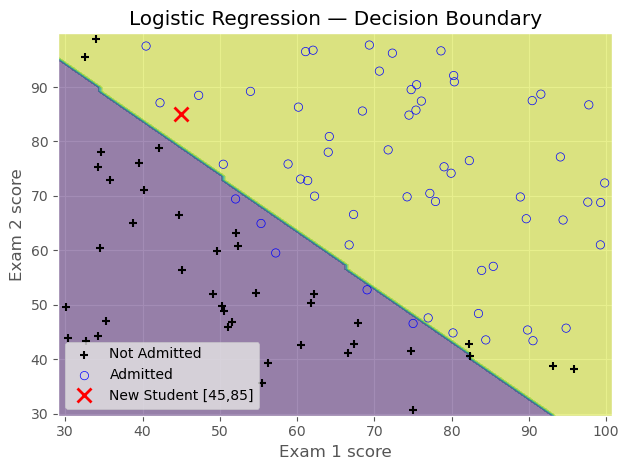

In [5]:
# 3. Plot decision boundary
plt.figure(figsize=(7, 5))
DecisionBoundaryDisplay.from_estimator(
    cdf, x, response_method='predict',
    xlabel='Exam 1 score', ylabel='Exam 2 score', alpha=0.5)
plt.scatter(x[neg, 0], x[neg, 1], marker='+', color='k', label='Not Admitted')
plt.scatter(x[pos, 0], x[pos, 1], marker='o',
            facecolors='none', edgecolors='b', label='Admitted')
plt.plot(45, 85, 'rx', markersize=10, markeredgewidth=2, label='New Student [45,85]')
plt.title('Logistic Regression — Decision Boundary')
plt.legend(); plt.tight_layout(); plt.show()


**Interpretation:** Logistic Regression draws a **linear decision boundary**. Each coefficient represents the log-odds change for a one-unit increase in the corresponding exam score.


## 4. Support Vector Machine (SVM)

**Instructions:**
1. Use `SVC` from scikit-learn
2. Fit the training dataset
3. Plot the decision boundary
4. Predict the class of `[45, 85]`

**Theory:** SVM finds the hyperplane that **maximises the margin** between the two classes.
Parameter `C` trades off margin width vs. training errors.


In [6]:
# 1 & 2. Fit SVM
svmc = svm.SVC(C=10)
svmc.fit(x, y)

# 4. Predict
pred_svm = svmc.predict([[45, 85]])
print(f'SVM Prediction for [45, 85]: {"Admitted" if pred_svm[0]==1 else "Not Admitted"}')
print(f'Number of support vectors per class: {svmc.n_support_}')


SVM Prediction for [45, 85]: Admitted
Number of support vectors per class: [11 10]


<Figure size 700x500 with 0 Axes>

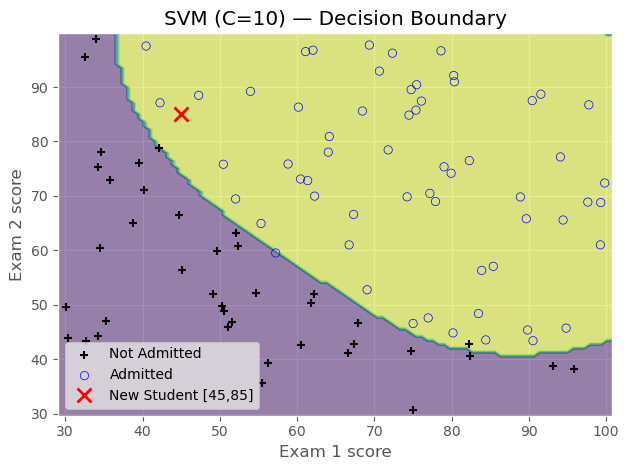

In [7]:
# 3. Plot decision boundary
plt.figure(figsize=(7, 5))
DecisionBoundaryDisplay.from_estimator(
    svmc, x, response_method='predict',
    xlabel='Exam 1 score', ylabel='Exam 2 score', alpha=0.5)
plt.scatter(x[neg, 0], x[neg, 1], marker='+', color='k', label='Not Admitted')
plt.scatter(x[pos, 0], x[pos, 1], marker='o',
            facecolors='none', edgecolors='b', label='Admitted')
plt.plot(45, 85, 'rx', markersize=10, markeredgewidth=2, label='New Student [45,85]')
plt.title('SVM (C=10) — Decision Boundary')
plt.legend(); plt.tight_layout(); plt.show()


## 5. K-Nearest Neighbours (KNN)

**Instructions:**
1. Fit the training set
2. Predict the class of `[45, 85]`
3. Find the nearest neighbours of `[45, 85]`

**Theory:** KNN classifies by majority vote among the $k$ nearest training points.
Small $k$ → complex boundary; large $k$ → smoother boundary.


In [8]:
# 1. Fit KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x, y)

# 2. Predict
pred_knn = knn.predict([[45, 85]])
print(f'KNN (k=3) Prediction for [45, 85]: {"Admitted" if pred_knn[0]==1 else "Not Admitted"}')

# 3. Find nearest neighbours
distances, indices = knn.kneighbors([[45, 85]])
print('Nearest neighbours:')
for dist, idx in zip(distances[0], indices[0]):
    print(f'  Index {idx}: scores={x[idx]}, label={"Admitted" if y[idx]==1 else "Not Admitted"}, dist={dist:.2f}')


KNN (k=3) Prediction for [45, 85]: Admitted
Nearest neighbours:
  Index 96: scores=[42.26170081 87.10385094], label=Admitted, dist=3.45
  Index 76: scores=[47.26426911 88.475865  ], label=Admitted, dist=4.15
  Index 86: scores=[42.07545454 78.844786  ], label=Not Admitted, dist=6.81


<Figure size 700x500 with 0 Axes>

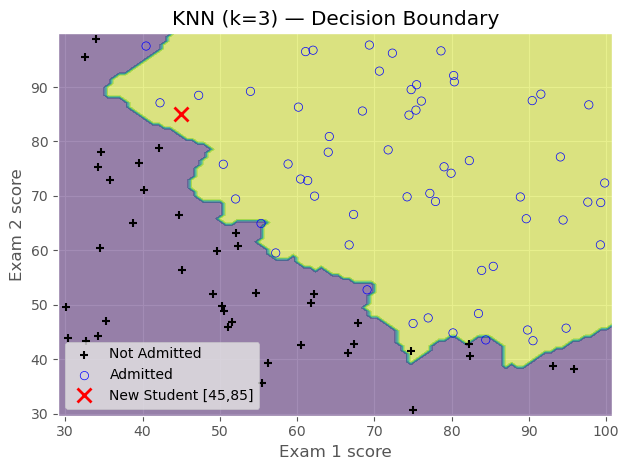

In [9]:
plt.figure(figsize=(7, 5))
DecisionBoundaryDisplay.from_estimator(
    knn, x, response_method='predict',
    xlabel='Exam 1 score', ylabel='Exam 2 score', alpha=0.5)
plt.scatter(x[neg, 0], x[neg, 1], marker='+', color='k', label='Not Admitted')
plt.scatter(x[pos, 0], x[pos, 1], marker='o',
            facecolors='none', edgecolors='b', label='Admitted')
plt.plot(45, 85, 'rx', markersize=10, markeredgewidth=2, label='New Student [45,85]')
plt.title('KNN (k=3) — Decision Boundary')
plt.legend(); plt.tight_layout(); plt.show()


## 6. Decision Tree

**Theory:** Decision Trees recursively split the feature space using threshold rules.
`max_depth` controls complexity: deep trees risk overfitting.


In [10]:
dtc = DecisionTreeClassifier(max_depth=10, random_state=0)
dtc.fit(x, y)
pred_dtc = dtc.predict([[45, 85]])
print(f'Decision Tree Prediction for [45, 85]: {"Admitted" if pred_dtc[0]==1 else "Not Admitted"}')
print(f'Tree depth: {dtc.get_depth()}  |  Leaves: {dtc.get_n_leaves()}')


Decision Tree Prediction for [45, 85]: Admitted
Tree depth: 4  |  Leaves: 9


<Figure size 700x500 with 0 Axes>

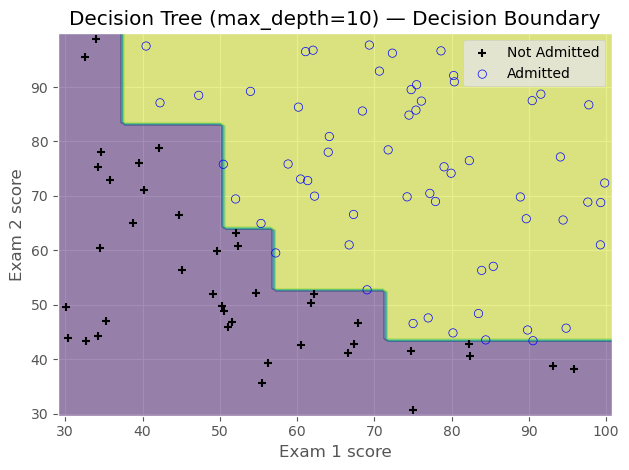

In [11]:
plt.figure(figsize=(7, 5))
DecisionBoundaryDisplay.from_estimator(
    dtc, x, response_method='predict',
    xlabel='Exam 1 score', ylabel='Exam 2 score', alpha=0.5)
plt.scatter(x[neg, 0], x[neg, 1], marker='+', color='k', label='Not Admitted')
plt.scatter(x[pos, 0], x[pos, 1], marker='o',
            facecolors='none', edgecolors='b', label='Admitted')
plt.title('Decision Tree (max_depth=10) — Decision Boundary')
plt.legend(); plt.tight_layout(); plt.show()


## 7. Model Comparison — Cross-Validated Accuracy

We compare all four classifiers using 5-fold cross-validation on the same dataset.


In [12]:
from sklearn.model_selection import cross_val_score

classifiers = {
    'Logistic Regression': LogisticRegression(random_state=0, max_iter=1000),
    'SVM (C=10)':          svm.SVC(C=10),
    'KNN (k=3)':           KNeighborsClassifier(n_neighbors=3),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=0),
}

print(f'{'Classifier':<25} {'5-fold CV Accuracy':>22}')
print('-' * 50)
for name, clf in classifiers.items():
    scores = cross_val_score(clf, x, y, cv=5, scoring='accuracy')
    print(f'{name:<25} {scores.mean():.3f} ± {scores.std():.3f}')


Classifier                    5-fold CV Accuracy
--------------------------------------------------
Logistic Regression       0.890 ± 0.020
SVM (C=10)                0.970 ± 0.024
KNN (k=3)                 0.880 ± 0.060
Decision Tree             0.920 ± 0.040


## 8. Repeat with Non-Linear Data

Now apply the same four classifiers to a non-linear dataset (e.g. from Assignment 2).
Observe how each decision boundary adapts to the non-linear class structure.


Note: using synthetic non-linear data for demonstration.


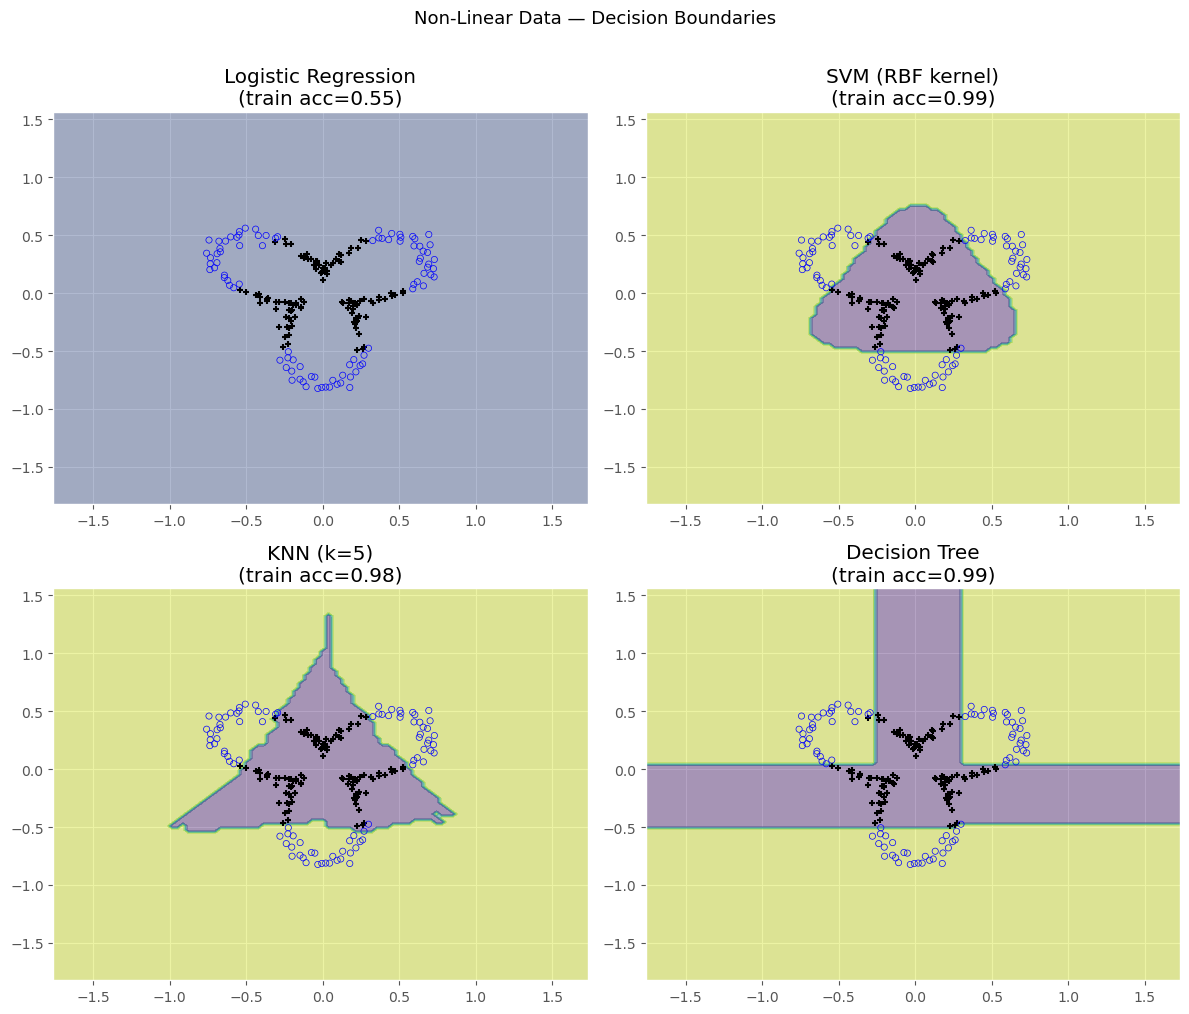

In [14]:
# Load the non-linear dataset from Assignment 2
# Replace 'ex2data2.txt' with the actual non-linear data file you have
try:
    nl_data = np.loadtxt('data/ex2data2.txt', dtype=float, delimiter=',')
except FileNotFoundError:
    # Generate a synthetic non-linearly separable dataset for demonstration
    np.random.seed(42)
    n = 200
    t = np.linspace(0, 2 * np.pi, n)
    r = 0.5 + 0.3 * np.sin(3 * t) + 0.05 * np.random.randn(n)
    x_nl = np.column_stack([r * np.cos(t), r * np.sin(t)])
    y_nl = (r > 0.55).astype(float)
    print("Note: using synthetic non-linear data for demonstration.")
else:
    x_nl = nl_data[:, :2]
    y_nl = nl_data[:, -1]

neg_nl = np.where(y_nl == 0)[0]
pos_nl = np.where(y_nl == 1)[0]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
clfs_nl = [
    ('Logistic Regression', LogisticRegression(random_state=0, max_iter=1000)),
    ('SVM (RBF kernel)',    svm.SVC(C=10, kernel='rbf')),
    ('KNN (k=5)',           KNeighborsClassifier(n_neighbors=5)),
    ('Decision Tree',       DecisionTreeClassifier(max_depth=5, random_state=0)),
]

for ax, (name, clf) in zip(axes.ravel(), clfs_nl):
    clf.fit(x_nl, y_nl)
    DecisionBoundaryDisplay.from_estimator(clf, x_nl, response_method='predict',
                                           ax=ax, alpha=0.4)
    ax.scatter(x_nl[neg_nl, 0], x_nl[neg_nl, 1], marker='+', color='k', s=20)
    ax.scatter(x_nl[pos_nl, 0], x_nl[pos_nl, 1], marker='o',
               facecolors='none', edgecolors='b', s=20)
    acc = clf.score(x_nl, y_nl)
    ax.set_title(f'{name}\n(train acc={acc:.2f})')

plt.suptitle('Non-Linear Data — Decision Boundaries', y=1.01, fontsize=13)
plt.tight_layout(); plt.show()


**Summary:**

| Classifier | Boundary | Best use case |
|---|---|---|
| Logistic Regression | Linear | Linearly separable data |
| SVM (RBF) | Non-linear | Complex shapes, medium datasets |
| KNN | Voronoi | Local structure, no training cost |
| Decision Tree | Axis-aligned | Interpretability required |

> No single algorithm wins on all datasets. Cross-validation is essential for fair comparison.
